## 1. PatchCore 모델 구성 및 정상 특징 학습

0. 데이터 불러오기

In [2]:
%pip install -q onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 59.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 68.5 MB/s eta 0:00:00:00:0100:01


In [3]:
%pip install -q --upgrade onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 17.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.7 MB/s eta 0:00:00


In [4]:
%pip install -q \
    "numpy==2.2.6" \
    "numba==0.61.2" \
    "anomalib==2.6.2" \
    jedi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 78.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 20.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 

In [5]:
%pip install --force-reinstall --no-cache-dir "numpy==2.1.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 329.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [6]:
from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.engine import Engine

import torch

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/dinomaly/components/layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


In [7]:
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


In [8]:
datamodule = MVTecAD(
    root="./datasets/MVTecAD",
    category="bottle",
    train_batch_size=32,
    eval_batch_size=32,
)

In [9]:
datamodule.prepare_data()
datamodule.setup()

mvtecad: 5.26GB [05:35, 15.7MB/s]                                


In [10]:
train_loader = datamodule.train_dataloader()

print("Train samples :", len(train_loader.dataset))
print("Train batches :", len(train_loader))

Train samples : 209
Train batches : 7


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [11]:
batch = next(iter(train_loader))

print("Image shape :", batch.image.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Image shape : torch.Size([32, 3, 900, 900])


1. PatchCore와 Engine 불러오기

In [12]:
from anomalib.models import Patchcore
from anomalib.engine import Engine

2. PatchCore 전처리 설정

In [13]:
pre_processor = Patchcore.configure_pre_processor(
    image_size=(256, 256),
    center_crop_size=(256, 256),
)

3. PatchCore 모델 생성

In [14]:
model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    pre_trained=True,
    coreset_sampling_ratio=0.1,
    num_neighbors=9,
    pre_processor=pre_processor,
)

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  276MB            

model.safetensors: downloading bytes:           |  0.00B            

4. 모델 구조 확인

In [15]:
print(model)

Patchcore(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          CenterCrop(size=(256, 256))
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          ExportableCenterCrop(size=[256, 256])
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PatchcoreModel(
  

5. Engine 생성

In [16]:
engine = Engine(
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)

6. PatchCore 정상 특징 학습

In [17]:
engine.fit(
    model=model,
    datamodule=datamodule,
)

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to 

In [18]:
memory_bank = model.model.memory_bank

print("Memory bank shape :", memory_bank.shape)
print("Feature dtype     :", memory_bank.dtype)
print("Stored on         :", memory_bank.device)

Memory bank shape : torch.Size([21401, 1536])
Feature dtype     : torch.float32
Stored on         : cpu


## 2. PatchCore 이상 탐지 성능 평가

1. 테스트 데이터 개수 확인

In [19]:
test_loader = datamodule.test_dataloader()

print("Test batches : ", len(test_loader))
print("Test samples : ", len(test_loader.dataset))

Test batches :  3
Test samples :  83


2. PatchCore 기본 평가 지표 확인

In [20]:
for metric in model.evaluator.test_metrics:
    print(metric.name)

image_AUROC
image_F1Score
pixel_AUROC
pixel_F1Score


3. 테스트 데이터 전체 평가

In [21]:
test_results = engine.test(
    model=model,
    datamodule=datamodule,
    verbose=False,
)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


4. 평가 결과 구조 확인

In [22]:
print(type(test_results))
print(test_results)

<class 'list'>
[{'image_AUROC': 1.0, 'image_F1Score': 0.9919999837875366, 'pixel_AUROC': 0.9856433272361755, 'pixel_F1Score': 0.7272753119468689}]


5. Image AUROC와 Pixel AUROC 확인

In [23]:
metrics = test_results[0]

image_auroc = metrics.get("image_AUROC")
pixel_auroc = metrics.get("pixel_AUROC")

print("Image AUROC :", image_auroc)
print("Pixel AUROC :", pixel_auroc)

Image AUROC : 1.0
Pixel AUROC : 0.9856433272361755


## 3. PatchCore 예측 결과 및 Anomaly Heatmap 시각화

1. 시각화할 불량 이미지 선택

In [24]:
from pathlib import Path

root = Path("./datasets/MVTecAD/bottle")

test_image_path = sorted(
    (root / "test" / "broken_large").glob("*.png")
)[0]

ground_truth_path = (
    root
    / "ground_truth"
    / "broken_large"
    / f"{test_image_path.stem}_mask.png"
)

print("Test image :", test_image_path)
print("GT mask    :", ground_truth_path)

Test image : datasets/MVTecAD/bottle/test/broken_large/000.png
GT mask    : datasets/MVTecAD/bottle/ground_truth/broken_large/000_mask.png


2. 선택한 이미지와 Ground Truth 확인

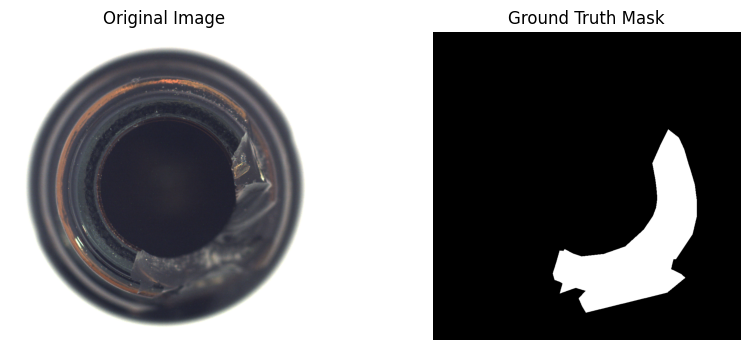

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

original_image = Image.open(test_image_path).convert("RGB")
ground_truth = Image.open(ground_truth_path).convert("L")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

3. PatchCore로 단일 이미지 추론

In [26]:
predictions = engine.predict(
    model=model,
    data_path=str(test_image_path),
    return_predictions=True,
)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


4. 예측 결과 구조 확인

In [27]:
print("Predictions type :", type(predictions))
print("Number of batches:", len(predictions))
print("First item type  :", type(predictions[0]))

Predictions type : <class 'list'>
Number of batches: 1
First item type  : <class 'anomalib.data.dataclasses.torch.image.ImageBatch'>


In [28]:
prediction = predictions[0]

5. Anomaly Score 확인

In [29]:
print("Prediction score:", prediction.pred_score)

Prediction score: tensor([0.9396])


6. Anomaly Map 크기 확인

In [30]:
print("Anomaly map shape:", prediction.anomaly_map.shape)

Anomaly map shape: torch.Size([1, 256, 256])


7. Tensor를 Numpy 배열로 변환

In [31]:
import numpy as np

anomaly_map = prediction.anomaly_map.detach().cpu().numpy()
anomaly_map = np.squeeze(anomaly_map)

print("Anomaly map shape:", anomaly_map.shape)
print("Minimum:", anomaly_map.min())
print("Maximum:", anomaly_map.max())

Anomaly map shape: (256, 256)
Minimum: 0.024999052
Maximum: 0.8306953


8. PatchCore Anomaly Map 단독 시각화

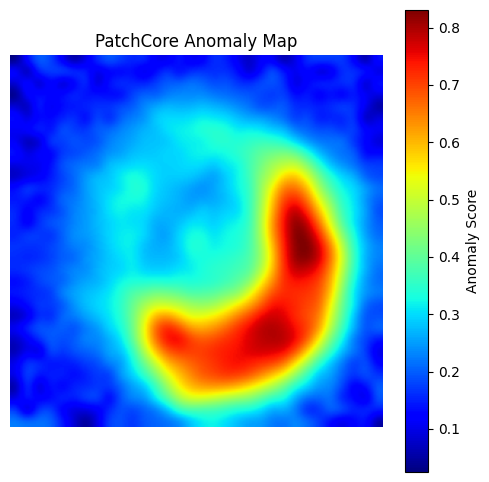

In [32]:
plt.figure(figsize=(6, 6))

plt.imshow(anomaly_map, cmap="jet")
plt.colorbar(label="Anomaly Score")

plt.title("PatchCore Anomaly Map")
plt.axis("off")

plt.show()

9. Heatmap을 원본 이미지 크기로 변환

In [33]:
from PIL import Image

original_array = np.array(original_image)

heatmap_image = Image.fromarray(
    anomaly_map.astype(np.float32)
)

heatmap_resized = heatmap_image.resize(
    original_image.size,
    resample=Image.Resampling.BILINEAR,
)

heatmap_resized = np.array(heatmap_resized)

print("Original image :", original_array.shape)
print("Resized heatmap:", heatmap_resized.shape)

Original image : (900, 900, 3)
Resized heatmap: (900, 900)


10. Heatmap 값을 0~1 범위로 정규화

In [34]:
heatmap_normalized = (
    (heatmap_resized - heatmap_resized.min())
    / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
)

11. 원본 이미지 위에 Heatmap Overlay

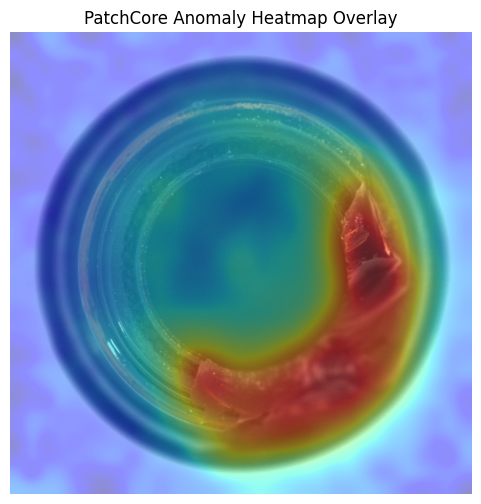

In [35]:
plt.figure(figsize=(6, 6))

plt.imshow(original_image)
plt.imshow(
    heatmap_normalized,
    cmap="jet",
    alpha=0.45,
)

plt.title("PatchCore Anomaly Heatmap Overlay")
plt.axis("off")

plt.show()

12. 네 개 결과 한번에 비교

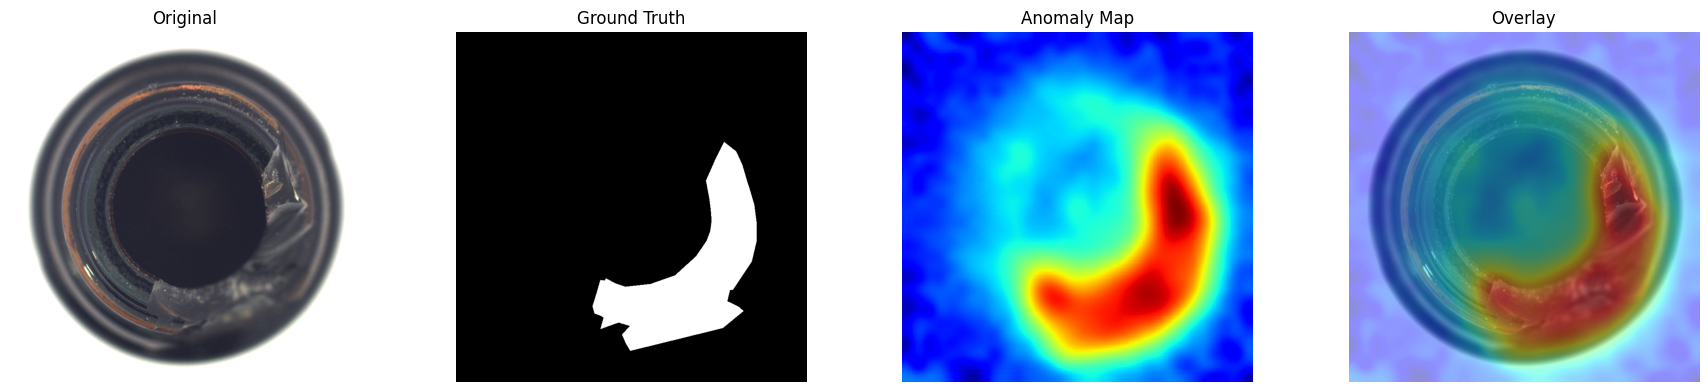

In [36]:
plt.figure(figsize=(18, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

# Ground Truth
plt.subplot(1, 4, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

# Anomaly Map
plt.subplot(1, 4, 3)
plt.imshow(anomaly_map, cmap="jet")
plt.title("Anomaly Map")
plt.axis("off")

# Overlay
plt.subplot(1, 4, 4)
plt.imshow(original_image)
plt.imshow(
    heatmap_normalized,
    cmap="jet",
    alpha=0.45,
)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. PatchCore 학습 결과 저장

1. 체크포인트 저장 경로 생성

In [37]:
from pathlib import Path

checkpoint_dir = Path("./models")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / "patchcore_bottle.ckpt"

print("Checkpoint path:", checkpoint_path)

Checkpoint path: models/patchcore_bottle.ckpt


2. PatchCore Checkpoint 저장

In [38]:
engine.trainer.save_checkpoint(checkpoint_path)

INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


3. 체크포인트 저장 확인

In [39]:
print("Exists:", checkpoint_path.exists())

if checkpoint_path.exists():
    size_mb = checkpoint_path.stat().st_size / (1024 ** 2)
    print(f"Checkpoint size: {size_mb:.2f} MB")

Exists: True
Checkpoint size: 220.60 MB


4. 현재 Colab 모델 파일 확인

In [40]:
!ls -lh ./models

total 221M
-rw-r--r-- 1 root root 221M Sep 16 02:27 patchcore_bottle.ckpt
